In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"E:\Bahare (important)\uni\Master\Data Visualization Project\Grok 2\customer_shopping_data.csv")

In [7]:
# Total revenue = quantity * price
df['total_price'] = df['quantity'] * df['price']

In [8]:
# Group by category
cat_rev = df.groupby('category')['total_price'].sum().sort_values(ascending=False) / 1_000_000  
cat_count = df.groupby('category').size()

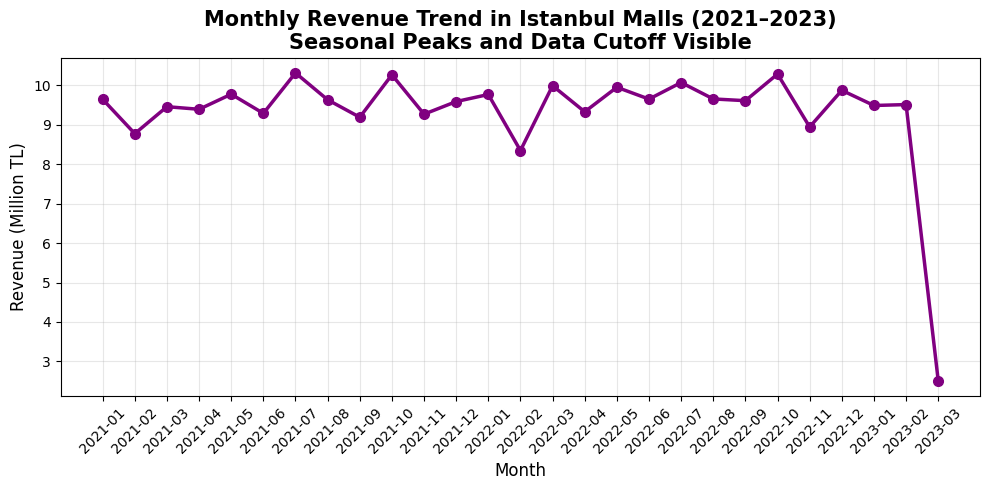

In [9]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst=True)
df['month_year'] = df['invoice_date'].dt.strftime('%Y-%m')

monthly_sales = df.groupby('month_year')['total_price'].sum() / 1_000_000

plt.figure(figsize=(10, 5))  # smaller figure, good for PPT

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    color='purple',
    linewidth=2.5,
    markersize=7
)

plt.title(
    'Monthly Revenue Trend in Istanbul Malls (2021–2023)\nSeasonal Peaks and Data Cutoff Visible',
    fontsize=15,
    fontweight='bold'
)

plt.ylabel('Revenue (Million TL)', fontsize=12)
plt.xlabel('Month', fontsize=12)

plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=300)
plt.show()


In [ ]:
df['total_price'] = df['quantity'] * df['price']
mall_revenue = df.groupby('shopping_mall')['total_price'].sum() / 1_000_000  # per million
mall_revenue = mall_revenue.sort_values(ascending=False).round(1)
mall_revenue

shopping_mall
Mall of Istanbul     50.9
Kanyon               50.6
Metrocity            37.3
Metropol AVM         25.4
Istinye Park         24.6
Zorlu Center         12.9
Cevahir AVM          12.6
Viaport Outlet       12.5
Emaar Square Mall    12.4
Forum Istanbul       12.3
Name: total_price, dtype: float64

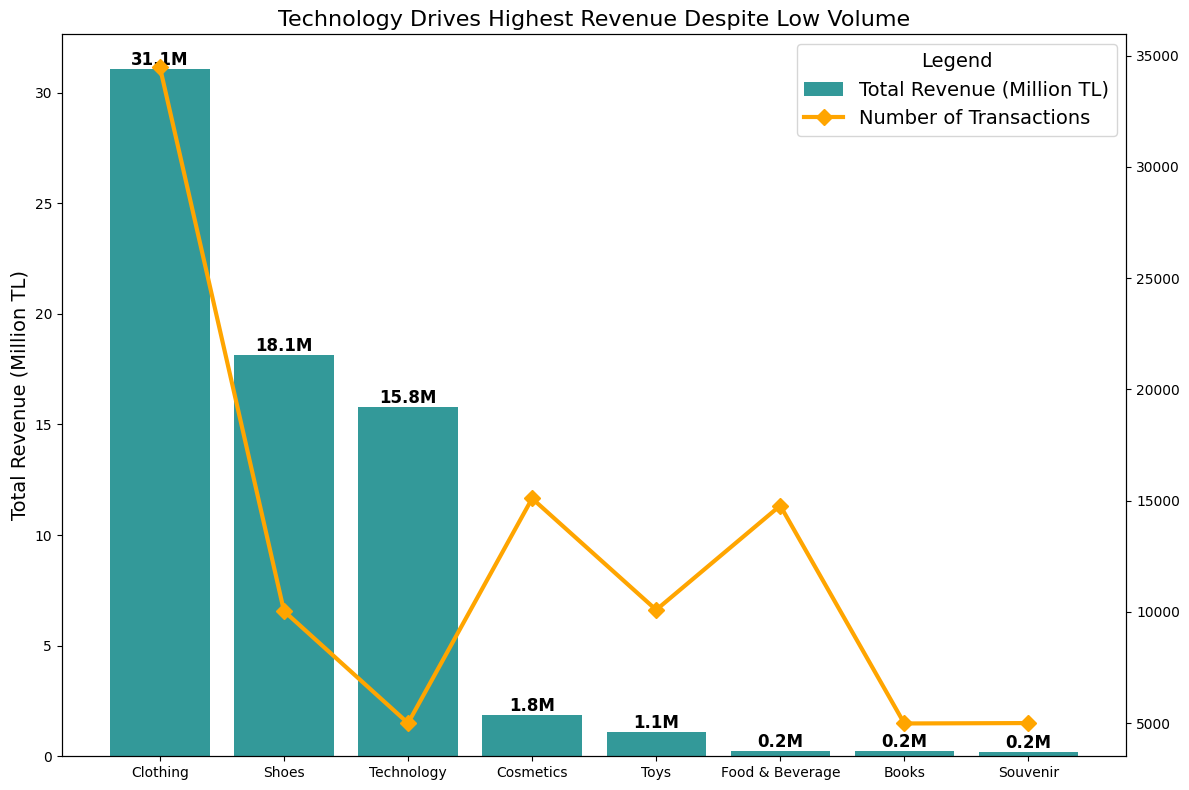

In [4]:

cat_rev = df.groupby('category')['price'].sum().sort_values(ascending=False) / 1_000_000
cat_count = df.groupby('category').size().reindex(cat_rev.index)  

fig, ax1 = plt.subplots(figsize=(12, 8))
bars = ax1.bar(
    cat_rev.index,
    cat_rev.values,
    color='teal',
    alpha=0.8,
    label='Total Revenue (Million TL)')
ax1.set_ylabel('Total Revenue (Million TL)', fontsize=14)
ax1.set_title('Technology Drives Highest Revenue Despite Low Volume', fontsize=16)

ax2 = ax1.twinx()
ax2.plot(
    cat_count.index,
    cat_count.values,
    color='orange',
    marker='D',
    linewidth=3,
    markersize=8,
    label='Number of Transactions')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()


ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right',
    fontsize=14,
    frameon=True,
    title='Legend',
    title_fontsize=14
)



plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{height:.1f}M', xy=(bar.get_x() + bar.get_width()/2, height), xytext=(0,3), textcoords="offset points", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('category_revenue_improved.png', dpi=300)
plt.show()

C:\Users\broba\AppData\Local\Temp\ipykernel_17316\2341841267.py:7: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  age_category = pd.pivot_table(


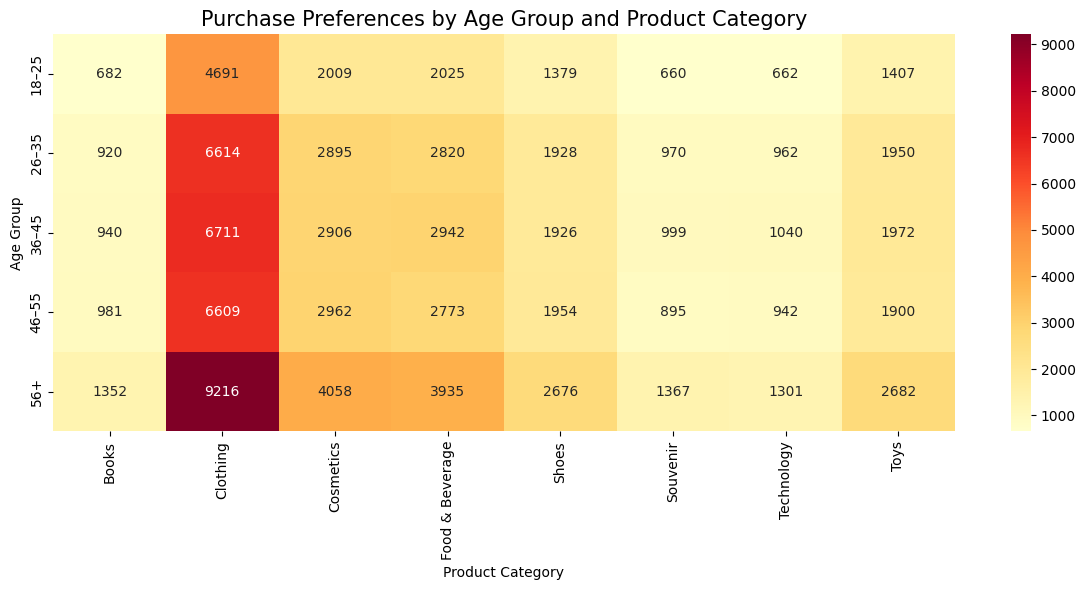

In [7]:
bins = [18, 25, 35, 45, 55, 100]
labels = ["18–25", "26–35", "36–45", "46–55", "56+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=True)

# Pivot table: count of purchases
age_category = pd.pivot_table(
    df,
    values="invoice_no",
    index="age_group",
    columns="category",
    aggfunc="count",
    fill_value=0
)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(age_category, annot=True, fmt="d", cmap="YlOrRd")

plt.title("Purchase Preferences by Age Group and Product Category", fontsize=15)
plt.xlabel("Product Category")
plt.ylabel("Age Group")

plt.tight_layout()
plt.savefig("age_category_heatmap.png", dpi=300)
plt.show()